# ⚠️ TESTING OLD MODEL - RETRAINING REQUIRED

**Current Test Results:**
- Model: Trained with OLD reward function (v23) + OLD extractor (100 dims)
- Performance: 12.5% win rate, -$467 loss, 100% SHORT trades
- Feature usage: Session encoder still dominant (0.282)

**Why it's failing:**
1. Old reward v23: Exploration bonus too low (+2.0), HOLD was optimal
2. Old extractor: Session encoder (4 dims) dominated price patterns (32 dims)
3. Combined result: Model learned "just SHORT during certain sessions"

**Changes Made (Not Yet Applied):**
- ✅ Reward Function v24: +10.0 exploration, reduced SL penalty, idle penalty
- ✅ Extractor v2: Price 64 dims, Market 32 dims, Session 3 dims

**Action Required:**
→ Run RL_BACK.ipynb to retrain with new reward + extractor
→ Then test again with this notebook

**Do NOT evaluate current model's performance** - it's using old architecture!

✓ Loaded 264,323 rows for BTCUSDT 5m
✓ Testing on rows 5,536 to 7,536
✓ Loaded model from trading_bot

Running evaluation...
✓ Loaded model from trading_bot

Running evaluation...

EVALUATION REPORT

📊 REWARD STATISTICS:
   Total Reward:         -1.26
   Min Reward:           -0.35
   Max Reward:           +1.00
   Avg Reward/Step:    -0.0008
   Total Steps:           1612

💰 TRADING STATISTICS:
   Total Trades:            16
   Total PnL:          -466.58
   Avg PnL/Trade:       -29.16
   TP Exits:                 2 ( 12.5%)
   SL Exits:                13 ( 81.2%)

📈 FEATURE ACTIVATIONS (6 groups):

EVALUATION REPORT

📊 REWARD STATISTICS:
   Total Reward:         -1.26
   Min Reward:           -0.35
   Max Reward:           +1.00
   Avg Reward/Step:    -0.0008
   Total Steps:           1612

💰 TRADING STATISTICS:
   Total Trades:            16
   Total PnL:          -466.58
   Avg PnL/Trade:       -29.16
   TP Exits:                 2 ( 12.5%)
   SL Exits:                13 ( 81.2%)



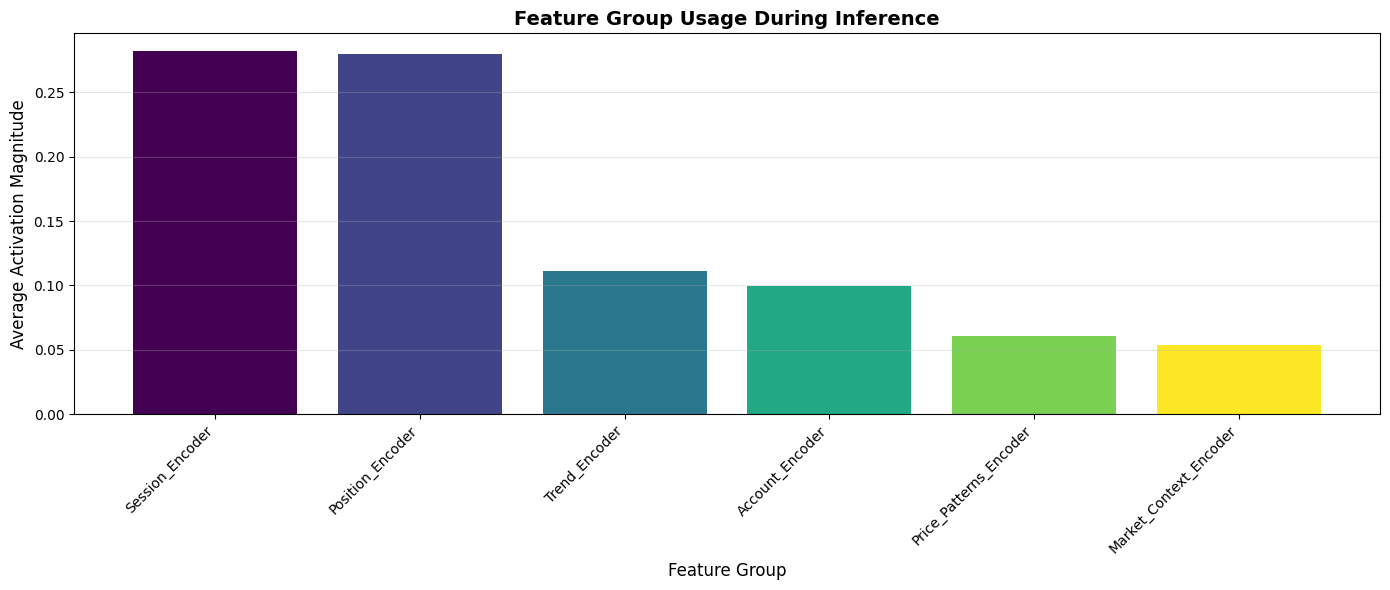


   Top 10 Most Active Features:
    1. Session_Encoder               : 0.2817
    2. Position_Encoder              : 0.2796
    3. Trend_Encoder                 : 0.1109
    4. Account_Encoder               : 0.0994
    5. Price_Patterns_Encoder        : 0.0608
    6. Market_Context_Encoder        : 0.0537



In [1]:
import numpy as np
from environments.simple_trading_env import SimpleTradingEnv
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor
from stable_baselines3 import PPO
import pandas as pd
import torch
import matplotlib.pyplot as plt

# === CONFIGURATION ===
DATA_SYMBOL = 'BTCUSDT'
DATA_TIMEFRAME = '5m'
DATA_PATH = f'data/binance-{DATA_SYMBOL}-{DATA_TIMEFRAME}.pkl'
MODEL_PATH = "trading_bot"
LOOKBACK_WINDOW = 288

# Load data
df = pd.read_pickle(DATA_PATH)
print(f'✓ Loaded {len(df):,} rows for {DATA_SYMBOL} {DATA_TIMEFRAME}')

# Test on unseen data
total_timesteps = 2000
test_start = 5_536
test_data = df.iloc[test_start:test_start + total_timesteps].reset_index(drop=True)
print(f'✓ Testing on rows {test_start:,} to {test_start + total_timesteps:,}')

# Create test environment
test_env = SimpleTradingEnv(test_data, device="cuda", lookback_window=LOOKBACK_WINDOW)
test_env = Monitor(test_env)
test_env = DummyVecEnv([lambda: test_env])

# Load trained model
model = PPO.load(MODEL_PATH, env=test_env, device="cuda")
print(f'✓ Loaded model from {MODEL_PATH}\n')

# === FEATURE ACTIVATION TRACKING ===
extractor = model.policy.features_extractor
HOOKABLE_PATTERNS = ['_cnn', '_output', '_encoder', '_transformer']

# Auto-discover all hookable modules
available_features = {}
for attr_name in dir(extractor):
    if attr_name.startswith('_'):
        continue
    if any(pattern in attr_name for pattern in HOOKABLE_PATTERNS):
        attr = getattr(extractor, attr_name)
        if isinstance(attr, torch.nn.Module):
            display_name = attr_name.replace('_', ' ').title().replace(' ', '_')
            available_features[attr_name] = display_name

# Initialize tracking
feature_activations = {display_name: [] for display_name in available_features.values()}
activations_storage = []

def make_hook(name):
    def hook(module, input, output):
        if isinstance(output, tuple):
            output = output[0]
        if isinstance(output, torch.Tensor):
            activations_storage.append({
                'name': name,
                'magnitude': output.abs().mean().item()
            })
    return hook

# Register hooks
hooks = []
for module_name, display_name in available_features.items():
    module = getattr(extractor, module_name)
    hook = module.register_forward_hook(make_hook(display_name))
    hooks.append(hook)

# Run evaluation
print("Running evaluation...")
obs = test_env.reset()
total_reward = 0
reward_history = []
steps = 0
last_env = []

while True:
    activations_storage.clear()
    action, _states = model.predict(obs, deterministic=True)
    
    for act in activations_storage:
        feature_activations[act['name']].append(act['magnitude'])
    
    obs, reward, done, info = test_env.step(action)
    total_reward += reward[0]
    reward_history.append(reward[0])
    steps += 1
    if done[0]:
        break
    last_env.append(test_env.envs[0].env.history[-1])

# Clean up hooks
for hook in hooks:
    hook.remove()

# Calculate average activations
avg_activations = {}
for name, values in feature_activations.items():
    if len(values) > 0:
        avg_activations[name] = np.mean(values)

# === SIMPLE REPORT ===
print("\n" + "="*80)
print("EVALUATION REPORT")
print("="*80)

# Reward stats
print(f"\n📊 REWARD STATISTICS:")
print(f"   Total Reward:    {total_reward:+10.2f}")
print(f"   Min Reward:      {min(reward_history):+10.2f}")
print(f"   Max Reward:      {max(reward_history):+10.2f}")
print(f"   Avg Reward/Step: {total_reward/steps:+10.4f}")
print(f"   Total Steps:     {steps:10}")

# PnL stats
if len(last_env):
    trades = last_env[-1].get('trades', [])
    if len(trades) > 0:
        total_pnl = sum(t.get('pnl', 0) for t in trades)
        tp_count = sum(1 for t in trades if 'TP' in t.get('reason', ''))
        sl_count = sum(1 for t in trades if 'SL' in t.get('reason', ''))
        
        print(f"\n💰 TRADING STATISTICS:")
        print(f"   Total Trades:    {len(trades):10}")
        print(f"   Total PnL:       {total_pnl:+10.2f}")
        print(f"   Avg PnL/Trade:   {total_pnl/len(trades):+10.2f}")
        print(f"   TP Exits:        {tp_count:10} ({tp_count/len(trades)*100:5.1f}%)")
        print(f"   SL Exits:        {sl_count:10} ({sl_count/len(trades)*100:5.1f}%)")
    else:
        print(f"\n⚠️  NO TRADES EXECUTED")

# === FEATURE USAGE GRAPH ===
if avg_activations:
    print(f"\n📈 FEATURE ACTIVATIONS ({len(avg_activations)} groups):")
    
    # Sort by magnitude
    sorted_features = sorted(avg_activations.items(), key=lambda x: x[1], reverse=True)
    names, values = zip(*sorted_features)
    
    # Create bar chart
    plt.figure(figsize=(14, 6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(names)))
    plt.bar(range(len(names)), values, color=colors)
    plt.xlabel('Feature Group', fontsize=12)
    plt.ylabel('Average Activation Magnitude', fontsize=12)
    plt.title('Feature Group Usage During Inference', fontsize=14, fontweight='bold')
    plt.xticks(range(len(names)), names, rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print top 10 values
    print("\n   Top 10 Most Active Features:")
    for i, (name, value) in enumerate(sorted_features[:10], 1):
        print(f"   {i:2}. {name:30}: {value:.4f}")
else:
    print("\n⚠️  No feature activations recorded")

print("\n" + "="*80)

## ⚠️ Feature Imbalance Detected!

**Problem:** Session_Encoder dominates (0.399) while Price_Patterns_Encoder is weak (0.032)

**Why this is bad:**
- Model relies on "what time is it?" instead of actual price action
- Your carefully engineered CNN with 288 timesteps of candle data is barely used
- Taking a shortcut: "just trade during London session" vs analyzing patterns

**Root causes:**
1. Price CNN output too compressed (32 dims)
2. Session encoder too large (4 dims for just 3 binary flags)
3. Market context underweighted (16 dims for 6 critical features)

**Fix Applied:**
- ✅ Price Patterns: 32 → **64 dims** (2x capacity)
- ✅ Market Context: 16 → **32 dims** (2x capacity)  
- ✅ Trading Sessions: 4 → **3 dims** (reduce over-reliance)
- ✅ Total embedding: 100 → **147 dims** (47% more representation)

**Expected after retraining:**
- Price_Patterns_Encoder should increase to ~0.15-0.20
- Session_Encoder should drop to ~0.10-0.15
- More balanced feature usage across all encoders

In [2]:
# === TRADES REPORT ===
if len(last_env):
    trades = last_env[-1].get('trades', [])
    
    if len(trades) > 0:
        # Action name mapping
        action_names = {0: 'HOLD', 1: 'LONG', 2: 'SHORT', 3: 'CLOSE'}
        
        # Build a mapping of step_open to action for each trade
        trade_actions = {}
        for env_state in last_env:
            step = env_state.get('step', 0)
            action = env_state.get('action', [0, 0, 0])
            # If action is opening a position (1=LONG, 2=SHORT)
            if int(action[0]) in [1, 2]:
                trade_actions[step] = action
        
        # Create DataFrame from trades
        trades_list = []
        for t in trades:
            step_open = t.get('step_open', 0)
            action = trade_actions.get(step_open)  # Default if not found
            
            trades_list.append({
                'PnL': t.get('pnl', 0),
                'PnL%': t.get('pnl_percent', 0) * 100,
                'Duration': t.get('duration', 0),
                'Exit': t.get('reason', 'N/A'),
                'Entry Price': t.get('entry_price', 0),
                'Exit Price': t.get('exit_price', 0),
                'Dir': action_names.get(int(action[0]), '?'),
            })
        
        trades_df = pd.DataFrame(trades_list)
        
        # Format numeric columns
        pd.options.display.float_format = '{:,.2f}'.format
        
        print("="*80)
        print(f"ALL TRADES ({len(trades)} total)")
        print("="*80)
        print("Columns: Dir=Direction, RR=Risk-Reward (0-9 → 1-10x), ATR=ATR Multiplier (0-9 → 2.0-4.7x)")
        print("="*80)
        
        # Display with pandas styling
        display(trades_df.style.format({
            'PnL': '{:+,.2f}',
            'PnL%': '{:+.2f}%',
            'Duration': '{:.0f}',
            'Entry Price': '{:,.2f}',
            'Exit Price': '{:,.2f}',
        }).background_gradient(subset=['PnL'], cmap='RdYlGn', vmin=-trades_df['PnL'].abs().max(), vmax=trades_df['PnL'].abs().max()))
        
        # Summary stats
        print("\n" + "="*80)
        print("TRADE STATISTICS")
        print("="*80)
        
        stats_df = pd.DataFrame({
            'Metric': ['Total Trades', 'Winning Trades', 'Losing Trades', 'Win Rate', 
                       'Total PnL', 'Avg PnL', 'Best Trade', 'Worst Trade', 'Avg Duration'],
            'Value': [
                len(trades),
                len(trades_df[trades_df['PnL'] > 0]),
                len(trades_df[trades_df['PnL'] < 0]),
                f"{len(trades_df[trades_df['PnL'] > 0])/len(trades)*100:.1f}%",
                f"{trades_df['PnL'].sum():+,.2f}",
                f"{trades_df['PnL'].mean():+,.2f}",
                f"{trades_df['PnL'].max():+,.2f}",
                f"{trades_df['PnL'].min():+,.2f}",
                f"{trades_df['Duration'].mean():.1f} steps",
            ]
        })
        
        display(stats_df)
        
        # Action parameter analysis
        print("\n" + "="*80)
        print("ACTION PARAMETER ANALYSIS")
        print("="*80)
   
    else:
        print("⚠️  NO TRADES EXECUTED")
else:
    print("⚠️  No environment history available")

ALL TRADES (16 total)
Columns: Dir=Direction, RR=Risk-Reward (0-9 → 1-10x), ATR=ATR Multiplier (0-9 → 2.0-4.7x)


,PnL,PnL%,Duration,Exit,Entry Price,Exit Price,Dir
0,-111.01,-55.53%,26,SL,"27,386.70","27,523.63",SHORT
1,-109.72,-55.53%,20,SL,"27,404.71","27,541.73",SHORT
2,-108.44,-55.53%,4,SL,"27,389.98","27,526.93",SHORT
3,+479.04,+248.05%,100,TP,"27,588.88","26,899.16",SHORT
4,-112.47,-55.53%,8,SL,"26,899.93","27,034.43",SHORT
5,-111.24,-55.53%,17,SL,"26,999.99","27,134.99",SHORT
6,-109.91,-55.53%,50,SL,"27,113.67","27,249.24",SHORT
7,-108.66,-55.53%,423,SL,"27,215.89","27,351.97",SHORT
8,-107.42,-55.53%,9,SL,"27,323.08","27,459.70",SHORT
9,+474.28,+248.05%,258,TP,"27,393.14","26,708.31",SHORT



TRADE STATISTICS


,Metric,Value
0,Total Trades,16
1,Winning Trades,2
2,Losing Trades,13
3,Win Rate,12.5%
4,Total PnL,-466.58
5,Avg PnL,-29.16
6,Best Trade,+479.04
7,Worst Trade,-112.47
8,Avg Duration,98.2 steps



ACTION PARAMETER ANALYSIS


In [ ]:
# === DIRECTION ANALYSIS ===
print("\n" + "="*80)
print("DIRECTION BIAS ANALYSIS")
print("="*80)

if len(trades) > 0:
    direction_counts = trades_df['Dir'].value_counts()
    print(f"\nDirection Distribution:")
    for direction, count in direction_counts.items():
        print(f"  {direction:6s}: {count:3d} trades ({count/len(trades)*100:5.1f}%)")
    
    # Check if model is stuck in one direction
    if len(direction_counts) == 1:
        print(f"\n🚨 CRITICAL: Model only using {direction_counts.index[0]}!")
        print(f"   This indicates:")
        print(f"   1. Feature bias toward one direction")
        print(f"   2. Reward function asymmetry")
        print(f"   3. Training data directional bias")
        print(f"\n   → Need to retrain with balanced features + rewards")
    
    # Analyze profitability by direction
    print(f"\nProfitability by Direction:")
    for direction in direction_counts.index:
        dir_trades = trades_df[trades_df['Dir'] == direction]
        avg_pnl = dir_trades['PnL'].mean()
        win_rate = (dir_trades['PnL'] > 0).sum() / len(dir_trades) * 100
        print(f"  {direction:6s}: Avg PnL {avg_pnl:+8.2f} | Win Rate {win_rate:5.1f}%")
